Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9570 - loss: 0.1411
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9860 - loss: 0.0460
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9906 - loss: 0.0311
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9926 - loss: 0.0233
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9941 - loss: 0.0178
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


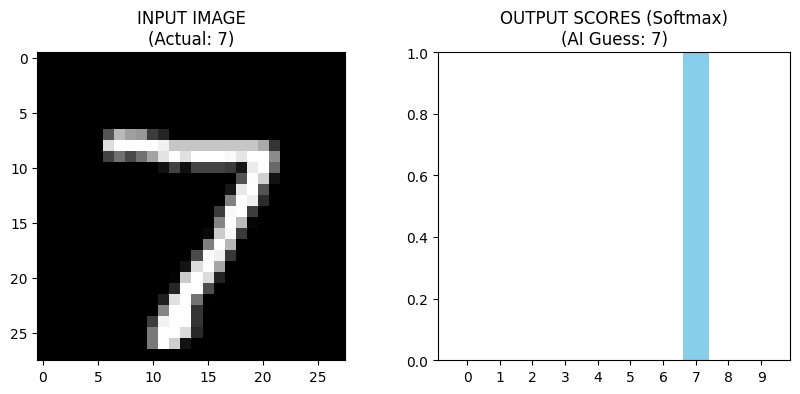

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: INPUT (The Raw Data) ---
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1)) / 255.0#255=gray scale or color image
test_images = test_images.reshape((10000, 28, 28, 1)) / 255.0

# --- STEP 2: THE MODEL (The Layers) ---
model = models.Sequential([
    # Feature Extraction (Red Bracket in your image)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), # C1
    layers.MaxPooling2D((2, 2)),                                         # S1
    layers.Conv2D(64, (3, 3), activation='relu'),                        # C2
    layers.MaxPooling2D((2, 2)),                                         # S2

    # Classification (Blue Bracket in your image)
    layers.Flatten(),                                                    # Flattening
    layers.Dense(64, activation='relu'),                                 # Fully Connected
    layers.Dense(10, activation='softmax')                               # Output (Softmax)
])

# --- STEP 3: TRAINING ---
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=3)

# --- STEP 4: VISUALIZING INPUT & OUTPUT FOR STUDENTS ---
def explain_prediction(index):
    img = test_images[index]
    true_label = test_labels[index]

    # AI makes a prediction
    prediction = model.predict(img.reshape(1, 28, 28, 1))
    predicted_label = np.argmax(prediction)

    # Plotting
    plt.figure(figsize=(10,4))

    # Show Input
    plt.subplot(1, 2, 1)
    plt.imshow(img.reshape(28,28), cmap='gray')
    plt.title(f"INPUT IMAGE\n(Actual: {true_label})")

    # Show Output (Probabilities)
    plt.subplot(1, 2, 2)
    plt.bar(range(10), prediction[0], color='skyblue')
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.title(f"OUTPUT SCORES (Softmax)\n(AI Guess: {predicted_label})")
    plt.show()

# Run for a sample image
explain_prediction(0)


model = models.Sequential([
    # Step A: Feature Extraction (Scanning for patterns)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='Conv_Layer_1'),
    layers.MaxPooling2D((2, 2), name='Maxpool_1'),
    layers.Conv2D(64, (3, 3), activation='relu', name='Conv_Layer_2'),
    layers.MaxPooling2D((2, 2), name='Maxpool_2'),

    # Step B: Classification (Decision making)
    layers.Flatten(),
    layers.Dense(64, activation='relu', name='Hidden_Neurons'),
    layers.Dense(10, activation='softmax', name='Output_Layer')
])